In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
import sys

sys.path.append("..")

import torch
import numpy as np
from einops import rearrange
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import Normalize

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [4]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)

In [99]:
from dataset.cyclone_diff import CycloneDiffusionDataset

data = CycloneDiffusionDataset(
    path="/local00/bioinf/gyrokinetics/preprocessed",
    split="train",
    normalization="minmax",
    normalization_scope="dataset",
    trajectories=["iteration_8.h5"],
    separate_zf=False,
    real_potens=False,
    conditions=["itg", "dg", "s_hat", "q"],
)

## Data visualization

In [50]:
def velocity_space_sample_3D(x, title=""):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]

    fig = plt.figure(figsize=(20, 20))
    fig.suptitle(title)

    fixed_axes = (2, 3, 4)
    slice_axes = (0, 1)

    global_min = np.inf
    global_max = -np.inf

    npar, nmu = 8, 2
    slice_idx = [
        [int(v_par), int(v_mu)]
        for v_par in np.linspace(9, 23, npar)
        for v_mu in np.linspace(1, 3, nmu)
    ]

    for idx in range(16):
        slice_point_0, slice_point_1 = slice_idx[idx]
        xx = x[slice_point_0, slice_point_1, :, :, :].numpy()
        global_min = min(global_min, xx.min())
        global_max = max(global_max, xx.max())

    cmap = "RdBu_r"

    for idx in range(16):
        ax_main = fig.add_subplot(4, 4, idx + 1, projection="3d")

        slice_point_0, slice_point_1 = slice_idx[idx]
        xx = x[slice_point_0, slice_point_1, :, :, :].numpy()

        ax_imshow = inset_axes(
            ax_main, width="30%", height="30%", loc="upper right", borderpad=-2.5
        )
        sliced_dims = x.mean(fixed_axes).T
        ax_imshow.matshow(sliced_dims, cmap="viridis", origin="lower")
        ax_imshow.scatter(slice_point_0, slice_point_1, color="red", marker="x")
        ax_imshow.set_xticks([])
        ax_imshow.set_yticks([])
        ax_imshow.grid(False)
        force_aspect(ax_imshow)

        X, Y, Z = np.meshgrid(
            np.arange(xx.shape[0]),
            np.arange(xx.shape[1]),
            np.arange(xx.shape[2]),
            indexing="ij",
        )

        scatter = ax_main.scatter(
            X.flatten(),
            Y.flatten(),
            Z.flatten(),
            c=xx.flatten(),
            cmap=cmap,
            alpha=0.4,
            vmin=global_min,
            vmax=global_max,
        )

        ax_main.set_xlabel(rf"${labels[fixed_axes[0]]}$", fontsize=20)
        ax_main.set_ylabel(rf"${labels[fixed_axes[1]]}$", fontsize=20)
        ax_main.set_zlabel(rf"${labels[fixed_axes[2]]}$", fontsize=20)

        ax_main.set_xticks([])
        ax_main.set_yticks([])
        ax_main.set_zticks([])
        ax_main.grid(False)

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(scatter, cax=cbar_ax)

    return fig

In [ ]:
_ = velocity_space_sample_3D(data[100].df[0])

In [ ]:
def animate_velocity_space_sample_3D(
    x,
    title="",
    surface_slices=None,
    alpha=1.0,
    cmap="RdBu_r",
    edgecolor="white",
    linewidth=0.3,
    interval=500,
):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]

    # Setup figure with single 3D axis
    fig = plt.figure(figsize=(10, 8))
    fig.suptitle(title)

    ax_main = fig.add_subplot(111, projection="3d")

    # Fixed and slice axes
    fixed_axes = (2, 3, 4)
    slice_axes = (0, 1)

    slice_idx = [
        [int(v_par), int(v_mu)]
        for v_mu in np.arange(0, x.shape[slice_axes[1]] // 2, 1)
        for v_par in np.arange(
            x.shape[slice_axes[0]] // 3, x.shape[slice_axes[0]] // 1.5, 1
        )
    ]

    # Calculate global min/max for consistent coloring
    global_min = np.inf
    global_max = -np.inf
    for v_par, v_mu in slice_idx:
        xx = x[v_par, v_mu, :, :, :].numpy()
        global_min = min(global_min, xx.min())
        global_max = max(global_max, xx.max())

    # Determine which Z-slices to plot as surfaces
    if surface_slices is None:
        # Default to showing 3 surfaces (min, middle, max)
        surface_slices = [0, x.shape[fixed_axes[2]] // 2, x.shape[fixed_axes[2]] - 1]
    else:
        surface_slices = np.linspace(
            0, x.shape[fixed_axes[2]] - 1, surface_slices, dtype=int
        )

    # Create meshgrid for surfaces (fixed for all frames)
    X, Y = np.meshgrid(
        np.arange(x.shape[fixed_axes[0]]),
        np.arange(x.shape[fixed_axes[1]]),
        indexing="ij",
    )

    # Store surface objects and initial facecolor arrays
    surfaces = []
    facecolor_arrays = []

    # Setup inset axes
    ax_imshow = inset_axes(
        ax_main, width="30%", height="30%", loc="upper right", borderpad=-2.5
    )
    sliced_dims = x.mean(fixed_axes).T
    img = ax_imshow.matshow(sliced_dims, cmap="RdBu_r", origin="lower")
    initial_slice = slice_idx[0]
    point = ax_imshow.scatter(
        initial_slice[0], initial_slice[1], color="red", marker="o"
    )
    ax_imshow.set_xticks([])
    ax_imshow.set_yticks([])
    ax_imshow.grid(False)

    # Set labels
    # ax_main.set_xlabel(rf"${labels[fixed_axes[0]]}$", fontsize=12)
    # ax_main.set_ylabel(rf"${labels[fixed_axes[1]]}$", fontsize=12)
    # ax_main.set_zlabel(rf"${labels[fixed_axes[2]]}$", fontsize=12)
    # ax_main.grid(False)

    # # Set consistent 3D view limits
    # ax_main.set_xlim(0, x.shape[fixed_axes[0]] - 1)
    # ax_main.set_ylim(0, x.shape[fixed_axes[1]] - 1)
    # ax_main.set_zlim(0, x.shape[fixed_axes[2]] - 1)

    ax_main.axis("off")

    cmap = matplotlib.colormaps[cmap]
    norm = plt.Normalize(global_min, global_max)

    # cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(global_min, global_max))
    # sm.set_array([])
    # fig.colorbar(sm, cax=cbar_ax, label="Value")

    # Create initial surfaces
    def create_surfaces(slice_point):
        v_par, v_mu = slice_point
        xx = x[v_par, v_mu, :, :, :].numpy()

        current_surfaces = []
        current_facecolors = []

        for k, z in enumerate(surface_slices):
            # Get face colors as 2D RGBA array
            facecolors_2d = cmap(norm(xx[:, :, z]))

            # Create surface plot
            Z_val = np.full_like(X, z)
            surf = ax_main.plot_surface(
                X,
                Y,
                Z_val,
                facecolors=facecolors_2d,
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha * (1 - 0.2 * k),
                shade=False,
                zorder=z,
            )

            current_surfaces.append(surf)
            current_facecolors.append(facecolors_2d.reshape(-1, 4))

        return current_surfaces, current_facecolors

    # Initial surfaces
    surfaces, facecolor_arrays = create_surfaces(initial_slice)

    # Animation update function
    def update(frame):
        nonlocal surfaces, facecolor_arrays

        # Remove old surfaces
        for surf in surfaces:
            surf.remove()

        # Create new surfaces for current frame
        v_par, v_mu = slice_idx[frame]
        surfaces, facecolor_arrays = create_surfaces((v_par, v_mu))

        # Update the red marker position
        point.set_offsets([[v_par, v_mu]])

        return surfaces + [point]

    # Create animation
    ani = FuncAnimation(
        fig, update, frames=len(slice_idx), interval=interval, blit=False
    )

    return ani

44.56448 mb


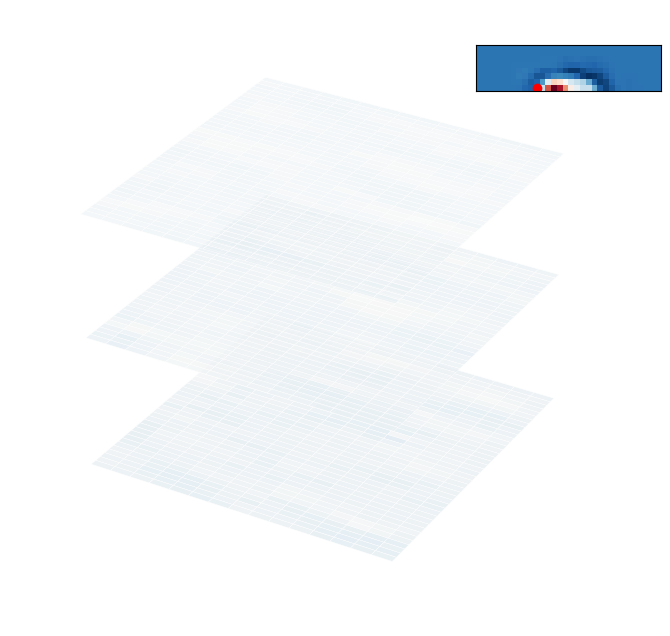

In [ ]:
x = data[100].df[0]

# x = x[::2, :, ::2, ::3]

print(x.nbytes / 1e6, "mb")

ani = animate_velocity_space_sample_3D(x)
ani.save("velocity_surfaces.gif", fps=5)
HTML(ani.to_jshtml())

In [ ]:
def animate_velocity_space_sample_3D_torus(
    x,
    title="",
    alpha=1.0,
    cmap="RdBu_r",
    edgecolor="white",
    linewidth=0.3,
    interval=500,
):
    labels = [r"v_{par}", r"v_{\mu}", r"s", r"k_x", r"k_y"]

    # Setup figure with single 3D axis
    fig = plt.figure(figsize=(10, 8))
    fig.suptitle(title)

    ax_main = fig.add_subplot(111, projection="3d")

    # Fixed and slice axes
    fixed_axes = (2, 3, 4)
    slice_axes = (0, 1)

    # Create slice points in sliding order
    npar, nmu = 8, 2
    v_par_values = np.linspace(9, 23, npar)
    v_mu_values = np.linspace(1, 3, nmu)

    slice_idx = []
    for i, v_mu in enumerate(v_mu_values):
        # Alternate direction for each row
        v_pars = v_par_values if i % 2 == 0 else v_par_values[::-1]
        for v_par in v_pars:
            slice_idx.append([int(v_par), int(v_mu)])

    # Calculate global min/max for consistent coloring
    global_min = np.inf
    global_max = -np.inf
    for v_par, v_mu in slice_idx:
        xx = x[v_par, v_mu, :, :, :].numpy()
        global_min = min(global_min, xx.min())
        global_max = max(global_max, xx.max())

    # Setup inset axes
    ax_imshow = inset_axes(
        ax_main, width="30%", height="30%", loc="upper right", borderpad=-2.5
    )
    sliced_dims = x.mean(fixed_axes).T
    img = ax_imshow.matshow(sliced_dims, cmap="RdBu_r", origin="lower")
    initial_slice = slice_idx[0]
    point = ax_imshow.scatter(
        initial_slice[0], initial_slice[1], color="red", marker="o"
    )
    ax_imshow.set_xticks([])
    ax_imshow.set_yticks([])
    ax_imshow.grid(False)

    # Turn off main axis
    ax_main.axis("off")

    # Create colormap and normalization
    cmap_obj = matplotlib.colormaps[cmap]
    norm = plt.Normalize(1.2 * global_min, 0.8 * global_max)

    # Torus parameters
    R = 3.0  # Major radius
    r = 1.5  # Minor radius

    # Create initial torus
    def create_torus(slice_point):
        v_par, v_mu = slice_point
        xx = x[v_par, v_mu, :, :, :].numpy()

        # Create angular grids
        n_theta = xx.shape[0]  # First dimension: rotational angle
        n_phi = xx.shape[1]  # Second dimension: poloidal angle

        theta = np.linspace(0, 2 * np.pi, n_theta)
        phi = np.linspace(0, 2 * np.pi, n_phi)
        Theta, Phi = np.meshgrid(theta, phi, indexing="ij")

        # Torus coordinates
        X = (R + r * np.cos(Phi)) * np.cos(Theta)
        Y = (R + r * np.cos(Phi)) * np.sin(Theta)
        Z = r * np.sin(Phi)

        # Create color array - map data values to colors
        # Use the third dimension as radial position
        radial_positions = np.linspace(0, 1, xx.shape[2])
        colors = np.zeros((n_theta, n_phi, 4))  # RGBA array

        # For each radial position, create a colored torus
        for k in range(xx.shape[2]):
            # Get color for this radial slice
            color_slice = cmap_obj(norm(xx[:, :, k]))

            # Create mask for this radial position
            # Radial position increases with k
            r_min = radial_positions[k] - 0.5 / xx.shape[2]
            r_max = radial_positions[k] + 0.5 / xx.shape[2]

            # Create radial mask
            radial_mask = (Phi >= 2 * np.pi * r_min) & (Phi < 2 * np.pi * r_max)

            # Apply color to masked region
            colors[radial_mask] = color_slice[radial_mask]

        # Create torus surface
        surf = ax_main.plot_surface(
            X,
            Y,
            Z,
            facecolors=colors,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            shade=False,
            zorder=3,
        )

        return surf

    # Initial torus
    torus = create_torus(initial_slice)

    # Set consistent view limits
    ax_main.set_xlim(-(R + r + 0.1), R + r + 0.1)
    ax_main.set_ylim(-(R + r + 0.1), R + r + 0.1)
    ax_main.set_zlim(-r - 0.1, r + 0.1)

    # Set initial view angle
    ax_main.view_init(elev=30, azim=45)

    # Animation update function
    def update(frame):
        nonlocal torus

        # Remove old torus
        torus.remove()

        # Create new torus for current frame
        v_par, v_mu = slice_idx[frame]
        torus = create_torus((v_par, v_mu))

        # Update the red marker position
        point.set_offsets([[v_par, v_mu]])

        return [torus, point]

    # Create animation
    ani = FuncAnimation(
        fig, update, frames=len(slice_idx), interval=interval, blit=False
    )

    return ani

44.56448 mb


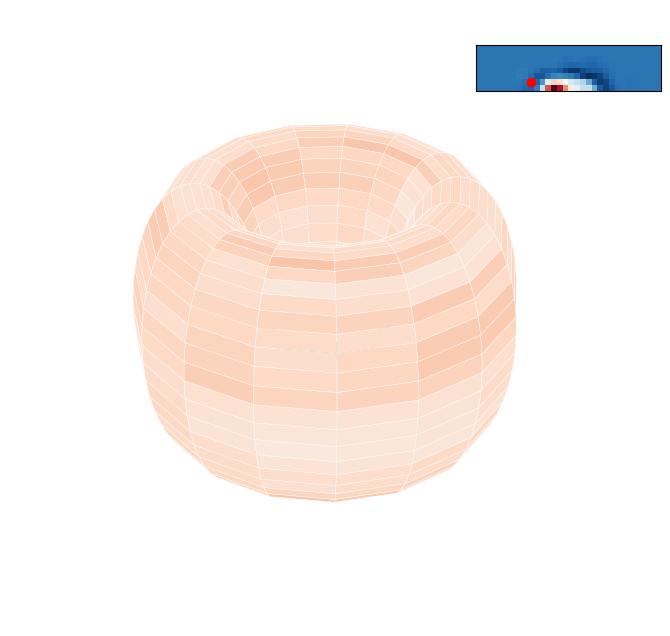

In [194]:
x = data[100].df[0]

# x = x[::2, :, ::2, ::3]

print(x.nbytes / 1e6, "mb")

ani = animate_velocity_space_sample_3D_torus(x)
HTML(ani.to_jshtml())

In [102]:
from matplotlib.patches import FancyArrowPatch
import mpl_toolkits.mplot3d.proj3d as proj3d


def animate_velocity_space_sample_3D_torus_v3(
    x,
    title="",
    alpha=1.0,
    cmap="RdBu_r",
    edgecolor="white",
    linewidth=0.1,
    interval=500,
):
    fig = plt.figure(figsize=(12, 10))
    fig.suptitle(title)

    ax_main = fig.add_subplot(111, projection="3d")

    fixed_axes = (2, 3, 4)
    slice_axes = (0, 1)

    # Torus parameters
    R = 4.0  # Major radius
    r = 2.5  # Minor radius

    v_par_values = np.arange(32 // 2 - 7, 32 // 2 + 8, 2)
    v_mu_values = np.arange(0, 3, 1)

    slice_idx = []
    for i, v_mu in enumerate(v_mu_values):
        v_pars = v_par_values if i % 2 == 0 else v_par_values[::-1]
        for v_par in v_pars:
            slice_idx.append([int(v_par), int(v_mu)])

    slice_idx = slice_idx + slice_idx[::-1]

    # global min/max for consistent coloring
    global_min = np.inf
    global_max = -np.inf
    for v_par, v_mu in slice_idx:
        xx = x[v_par, v_mu, :, :, :].numpy()
        global_min = min(global_min, xx.min())
        global_max = max(global_max, xx.max())

    # vspace subplot
    ax_imshow = fig.add_axes([0.6, 0.59, 0.2, 0.2])
    sliced_dims = x.mean(fixed_axes).T
    img = ax_imshow.matshow(sliced_dims, cmap="RdBu_r", origin="lower")
    initial_slice = slice_idx[0]
    point = ax_imshow.scatter(
        initial_slice[0], initial_slice[1], color="#19FC46", marker="o"
    )
    ax_imshow.set_xticks([])
    ax_imshow.set_yticks([])
    ax_imshow.grid(False)
    ax_imshow.set_xlabel(r"$v_{\parallel}$", fontsize=20)
    mulabel = ax_imshow.set_ylabel(r"$\mu$", rotation=0, fontsize=20, labelpad=15)
    mulabel.set_position((-0.15, 0.25))

    # x and y axes in top right (on the radius, hopefully)
    ax_xy = fig.add_axes([0.65, 0.37, 0.15, 0.15])
    ax_xy.set_xlim(-1, 1)
    ax_xy.set_ylim(-1, 1)
    ax_xy.axis("off")

    ax_xy.arrow(
        0, 0, 0.7, -0.3, head_width=0.1, head_length=0.15, fc="k", ec="k", linewidth=2.5
    )
    ax_xy.arrow(
        0, 0, 0, 0.8, head_width=0.1, head_length=0.15, fc="k", ec="k", linewidth=2.5
    )

    ax_xy.text(0.85, -0.10, r"$x$", fontsize=25, ha="center", va="center")
    ax_xy.text(-0.19, 0.96, r"$y$", fontsize=25, ha="center", va="center")

    # line through torus (s axis)
    ax_main.plot(
        [0, 0],
        [0, 0],
        [-r - 1, r + 1],
        color="k",
        linestyle="-",
        linewidth=1.5,
        zorder=1,
    )

    # circular arrow around z-axis
    class Arrow3D(FancyArrowPatch):
        def __init__(self, xs, ys, zs, *args, **kwargs):
            super().__init__((0, 0), (0, 0), *args, **kwargs)
            self._verts3d = xs, ys, zs

        def do_3d_projection(self, renderer=None):
            xs3d, ys3d, zs3d = self._verts3d
            xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
            self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
            return np.min(zs)

    # Add circular arrow around z-axis
    arrow_radius = R + r + 1.0
    arrow_theta = np.linspace(
        0, 1.8 * np.pi, 100
    )  # 1.8pi creates a small gap for arrow
    arrow_x = arrow_radius * np.cos(arrow_theta)
    arrow_y = arrow_radius * np.sin(arrow_theta)
    arrow_z = np.zeros_like(arrow_theta)

    # Plot circular line without last segment
    ax_main.plot(
        arrow_x[:-1], arrow_y[:-1], arrow_z[:-1], "k-", linewidth=2.5, zorder=1
    )

    # Add arrowhead at the end
    arrow_head = Arrow3D(
        [arrow_x[-2], arrow_x[-1]],
        [arrow_y[-2], arrow_y[-1]],
        [arrow_z[-2], arrow_z[-1]],
        mutation_scale=20,  # arrowhead size
        arrowstyle="-|>",  # Arrow style: line with arrowhead
        color="k",
        linewidth=1.5,
        zorder=1,
    )
    ax_main.add_artist(arrow_head)

    # s label at the top left
    ax_main.text(
        0,
        arrow_radius + 0.5,
        0,
        r"$s$",
        color="k",
        fontsize=25,
        ha="center",
        va="center",
        zorder=10,
    )
    ax_main.axis("off")

    # Create colormap and normalization
    cmap_obj = matplotlib.colormaps[cmap]
    norm = plt.Normalize(1.5 * global_min, 0.7 * global_max)

    # Create wireframe torus (static container)
    def create_wireframe_torus():
        # Create angular grid for wireframe
        n_wire = 20  # Resolution for wireframe
        theta_wire = np.linspace(0, 2 * np.pi, n_wire)
        phi_wire = np.linspace(0, 2 * np.pi, n_wire)
        Theta_wire, Phi_wire = np.meshgrid(theta_wire, phi_wire)

        # Wireframe torus coordinates
        X_wire = (R + r * np.cos(Phi_wire)) * np.cos(Theta_wire)
        Y_wire = (R + r * np.cos(Phi_wire)) * np.sin(Theta_wire)
        Z_wire = r * np.sin(Phi_wire)

        # Plot wireframe
        wire = ax_main.plot_wireframe(
            X_wire,
            Y_wire,
            Z_wire,
            color="gray",
            linewidth=0.7,
            alpha=0.1,
            rstride=2,
            cstride=2,
            zorder=1,
        )
        return wire

    # Create initial wireframe
    wireframe = create_wireframe_torus()

    # Create initial torus slices
    def create_torus_slices(slice_point):
        v_par, v_mu = slice_point
        xx = x[v_par, v_mu, :, :, :].numpy()

        # Get dimensions
        n_s = xx.shape[0]  # First fixed axis (s) - toroidal direction
        n_kx = xx.shape[1]  # Second fixed axis (k_x) - first perpendicular direction
        n_ky = xx.shape[2]  # Third fixed axis (k_y) - second perpendicular direction

        # Create angular grid for toroidal direction (s)
        theta = np.linspace(0, 2 * np.pi, n_s)

        # Create grid for perpendicular planes (k_x, k_y)
        # Scale to fit inside wireframe torus
        kx = np.linspace(-r, r, n_kx)
        ky = np.linspace(-r, r, n_ky)
        Kx, Ky = np.meshgrid(kx, ky, indexing="ij")

        # Initialize position arrays
        X = np.zeros((n_s, n_kx, n_ky))
        Y = np.zeros((n_s, n_kx, n_ky))
        Z = np.zeros((n_s, n_kx, n_ky))

        # Initialize color array
        colors = np.zeros((n_s, n_kx, n_ky, 4))

        # For each toroidal angle (s)
        for i, t in enumerate(theta):
            # Calculate the normal vector at this toroidal angle
            nx = np.cos(t)
            ny = np.sin(t)

            # Calculate the binormal vector (perpendicular to normal and z-axis)
            bx = -np.sin(t)
            by = np.cos(t)

            scale = 0.8

            X[i] = (R + Kx * nx + Ky * bx) * np.cos(t) * scale
            Y[i] = (R + Kx * nx + Ky * bx) * np.sin(t) * scale
            Z[i] = (Ky * by + Kx * ny) * scale

            # Set colors for this plane
            colors[i] = cmap_obj(norm(xx[i]))

        # Create surface for each perpendicular plane
        surfaces = []
        for i in range(n_s):
            # Create surface for this toroidal slice
            surf = ax_main.plot_surface(
                X[i],
                Y[i],
                Z[i],
                facecolors=colors[i],
                edgecolor=edgecolor,
                linewidth=linewidth,
                alpha=alpha,
                shade=False,
                zorder=0,
            )
            surfaces.append(surf)

        return surfaces

    # Initial torus slices
    slices = create_torus_slices(initial_slice)

    # Set consistent view limits
    max_extent = R + r + 0.5
    ax_main.set_xlim(-max_extent, max_extent)
    ax_main.set_ylim(-max_extent, max_extent)
    ax_main.set_zlim(-max_extent, max_extent)

    # Set initial view angle
    ax_main.view_init(elev=30, azim=45)

    def update(frame):
        nonlocal slices

        for surf in slices:
            surf.remove()

        v_par, v_mu = slice_idx[frame]
        slices = create_torus_slices((v_par, v_mu))

        # update the marker
        point.set_offsets([[v_par, v_mu]])

        return slices + [point]

    # Create animation
    ani = FuncAnimation(
        fig,
        update,
        frames=len(slice_idx),
        interval=interval,
        blit=False,
    )

    return ani

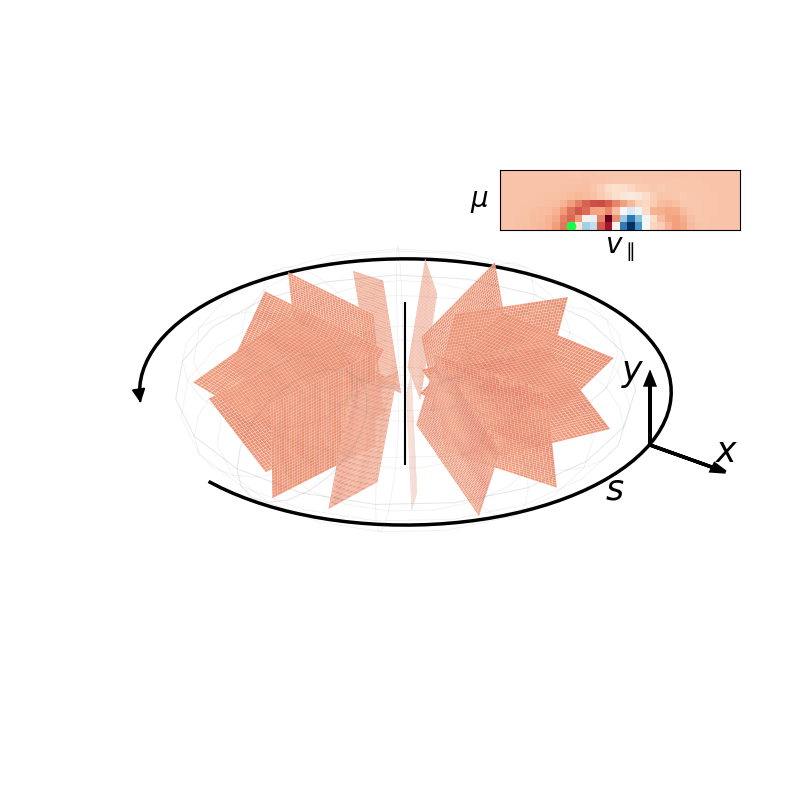

In [103]:
x = data[180].df.sum(0)

ani = animate_velocity_space_sample_3D_torus_v3(x)
ani.save("velocity_surfaces_long.gif", fps=5)
# HTML(ani.to_jshtml())

In [41]:
def plot3D(
    x,
    fixed_axes=(2, 3),
    title="",
    subs_2d=(1, 1),
    subs_3d=(1, 1, 1),
    alpha=1.0,
    cmap="RdBu_r",
    bg_alpha=0.0,
    surface_slices=None,  # Number of Z-slices to show as surfaces
    edgecolor="white",  # Color of the surface grid lines
    linewidth=0.3,  # Width of the grid lines
):
    # Validate subsampling parameters
    if len(subs_2d) != 2:
        raise ValueError("subs_2d must be a tuple of length 2")
    if len(subs_3d) != 3:
        raise ValueError("subs_3d must be a tuple of length 3")

    fixed_axis1, fixed_axis2 = fixed_axes
    slice_axes = [i for i in range(5) if i not in fixed_axes]

    # Determine grid size with axis-specific subsampling
    n1, n2 = x.shape[fixed_axis1], x.shape[fixed_axis2]
    plane_indices1 = range(0, n1, subs_2d[0])
    plane_indices2 = range(0, n2, subs_2d[1])
    n_rows = len(plane_indices1)
    n_cols = len(plane_indices2)

    fig = plt.figure(figsize=(2 * len(plane_indices2), 2 * len(plane_indices1)))

    # Find global min/max for consistent coloring
    global_min = np.inf
    global_max = -np.inf
    global_mean_min = np.inf
    global_mean_max = -np.inf
    slice_means = []  # Store means for background colors

    for i in plane_indices1:
        for j in plane_indices2:
            idx = [slice(None)] * 5
            idx[fixed_axis1] = i
            idx[fixed_axis2] = j
            xx = x[tuple(idx)].numpy()
            global_min = min(global_min, xx.min())
            global_max = max(global_max, xx.max())
            slice_means.append(xx.mean())
            global_mean_min = min(global_mean_min, xx.mean())
            global_mean_max = max(global_mean_max, xx.mean())

    norm = plt.Normalize(global_mean_min, global_mean_max)

    def make_faint_color(mean_val):
        rgba = matplotlib.colormaps[cmap](norm(mean_val))
        return (rgba[0], rgba[1], rgba[2], bg_alpha)

    bg_colors = [make_faint_color(mean) for mean in slice_means]

    # Create a gridspec with no spacing between subplots
    gs = fig.add_gridspec(
        n_rows, n_cols, left=0, right=1, bottom=0, top=1, wspace=0, hspace=0
    )

    # Create all plots
    plot_idx = 0
    for i, row in enumerate(plane_indices1):
        for j, col in enumerate(plane_indices2):
            ax = fig.add_subplot(
                gs[i, j], projection="3d", facecolor=bg_colors[plot_idx], alpha=bg_alpha
            )
            plot_idx += 1

            # Get the data slice
            idx = [slice(None)] * 5
            idx[fixed_axis1] = row
            idx[fixed_axis2] = col
            xx = x[tuple(idx)].numpy()

            # Subsample the data
            xx = xx[:: subs_3d[0], :: subs_3d[1], :: subs_3d[2]]

            # Create meshgrid for X and Y
            X, Y = np.meshgrid(
                np.arange(0, xx.shape[0]), np.arange(0, xx.shape[1]), indexing="ij"
            )

            # Determine which Z-slices to plot as surfaces
            if surface_slices is None:
                # Default to showing 3 surfaces (min, middle, max)
                z_indices = [0, xx.shape[2] // 2, xx.shape[2] - 1]
            else:
                z_indices = np.linspace(0, xx.shape[2] - 1, surface_slices, dtype=int)

            # Plot each surface with decreasing alpha based on Z position
            for k, z in enumerate(z_indices):
                Z_val = np.full_like(X, z)
                ax.plot_surface(
                    X,
                    Y,
                    Z_val,
                    facecolors=matplotlib.colormaps[cmap](
                        plt.Normalize(global_min, global_max)(xx[:, :, z])
                    ),
                    edgecolor=edgecolor,  # Set grid line color
                    linewidth=linewidth,  # Set grid line width
                    alpha=alpha * (1 - 0.2 * k),  # Slightly fade further surfaces
                    shade=False,
                    zorder=z,
                )

            # Remove all axes and frames
            ax.set_axis_off()
            ax.grid(False)

    # Adjust the suptitle position to account for no padding
    fig.subplots_adjust(top=0.95 if title else 1.0)

    return fig

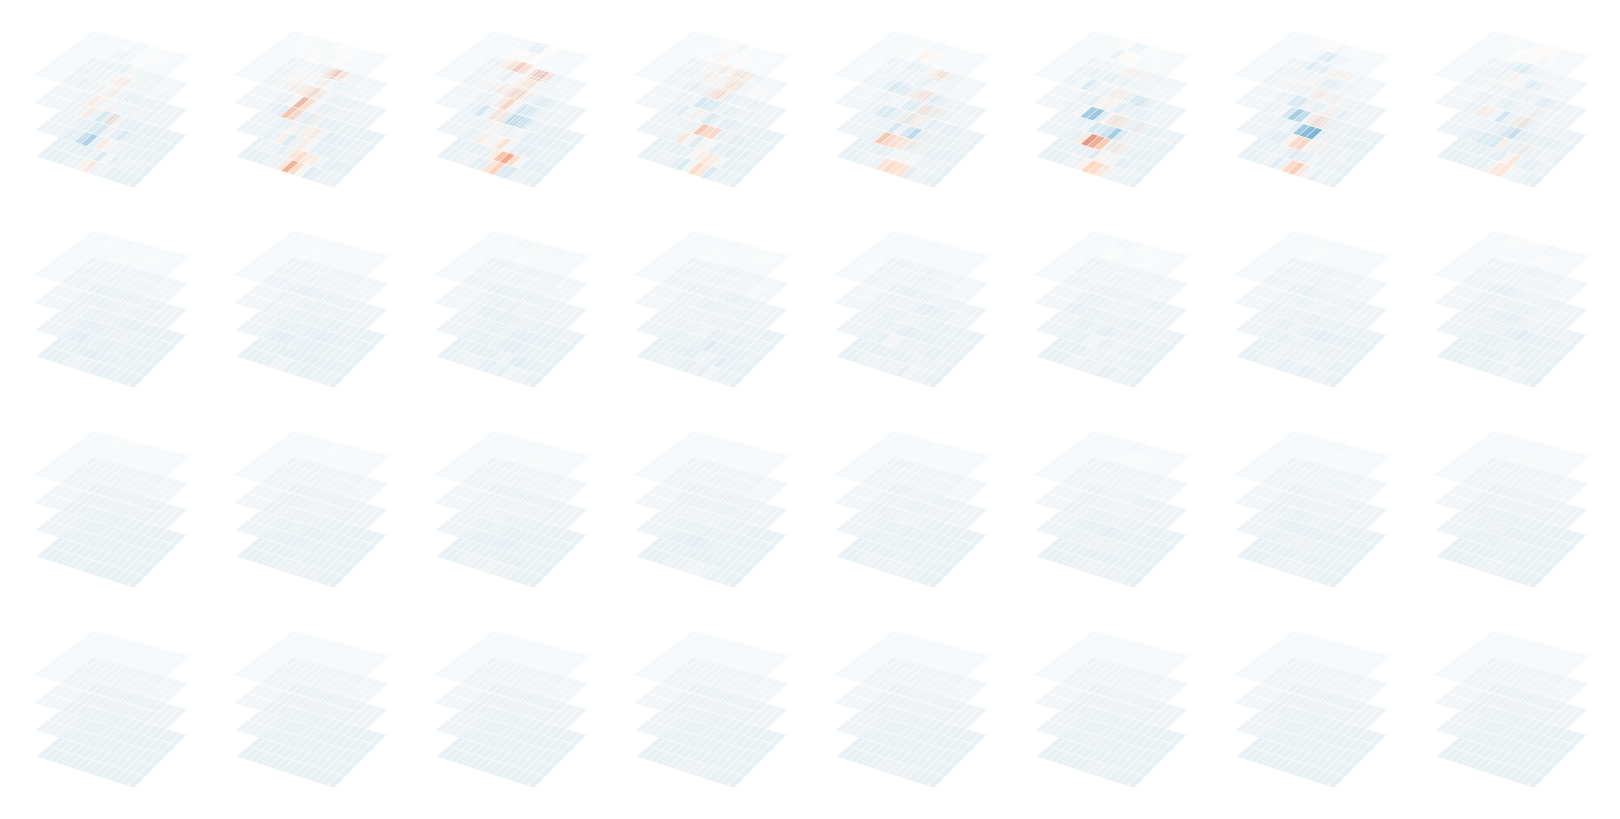

In [46]:
x = data[100].df[0]

fig = plot3D(x, fixed_axes=(1, 2), subs_2d=(2, 2), subs_3d=(2, 16, 2), surface_slices=4)

In [142]:
import numpy as np
import matplotlib.colors


def plot2D_ortho(
    x,
    fixed_axes=(2, 3),
    subs_2d=(1, 1),
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    elev=30,
    azim=-45,
):
    slice_axes = [i for i in range(5) if i not in fixed_axes]
    if hasattr(x, "numpy"):
        x = x.numpy()

    projection = np.mean(x, axis=tuple(slice_axes))
    n1, n2 = projection.shape[0], projection.shape[1]

    fig = plt.figure(figsize=(20, 20))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_proj_type("ortho")
    ax.view_init(elev=elev, azim=azim)
    projection = projection[:: subs_2d[0], :: subs_2d[1]]

    X, Y = np.meshgrid(
        np.arange(0, projection.shape[0]),
        np.arange(0, projection.shape[1]),
        indexing="ij",
    )
    norm = matplotlib.colors.Normalize(
        vmin=projection.min() if vmin is None else vmin,
        vmax=projection.max() if vmax is None else vmax,
    )

    ax.plot_surface(
        X,
        Y,
        np.zeros_like(projection),
        facecolors=plt.get_cmap(cmap)(norm(projection)),
        shade=False,
        rstride=1,
        cstride=1,
    )

    ax.set_axis_off()
    return fig

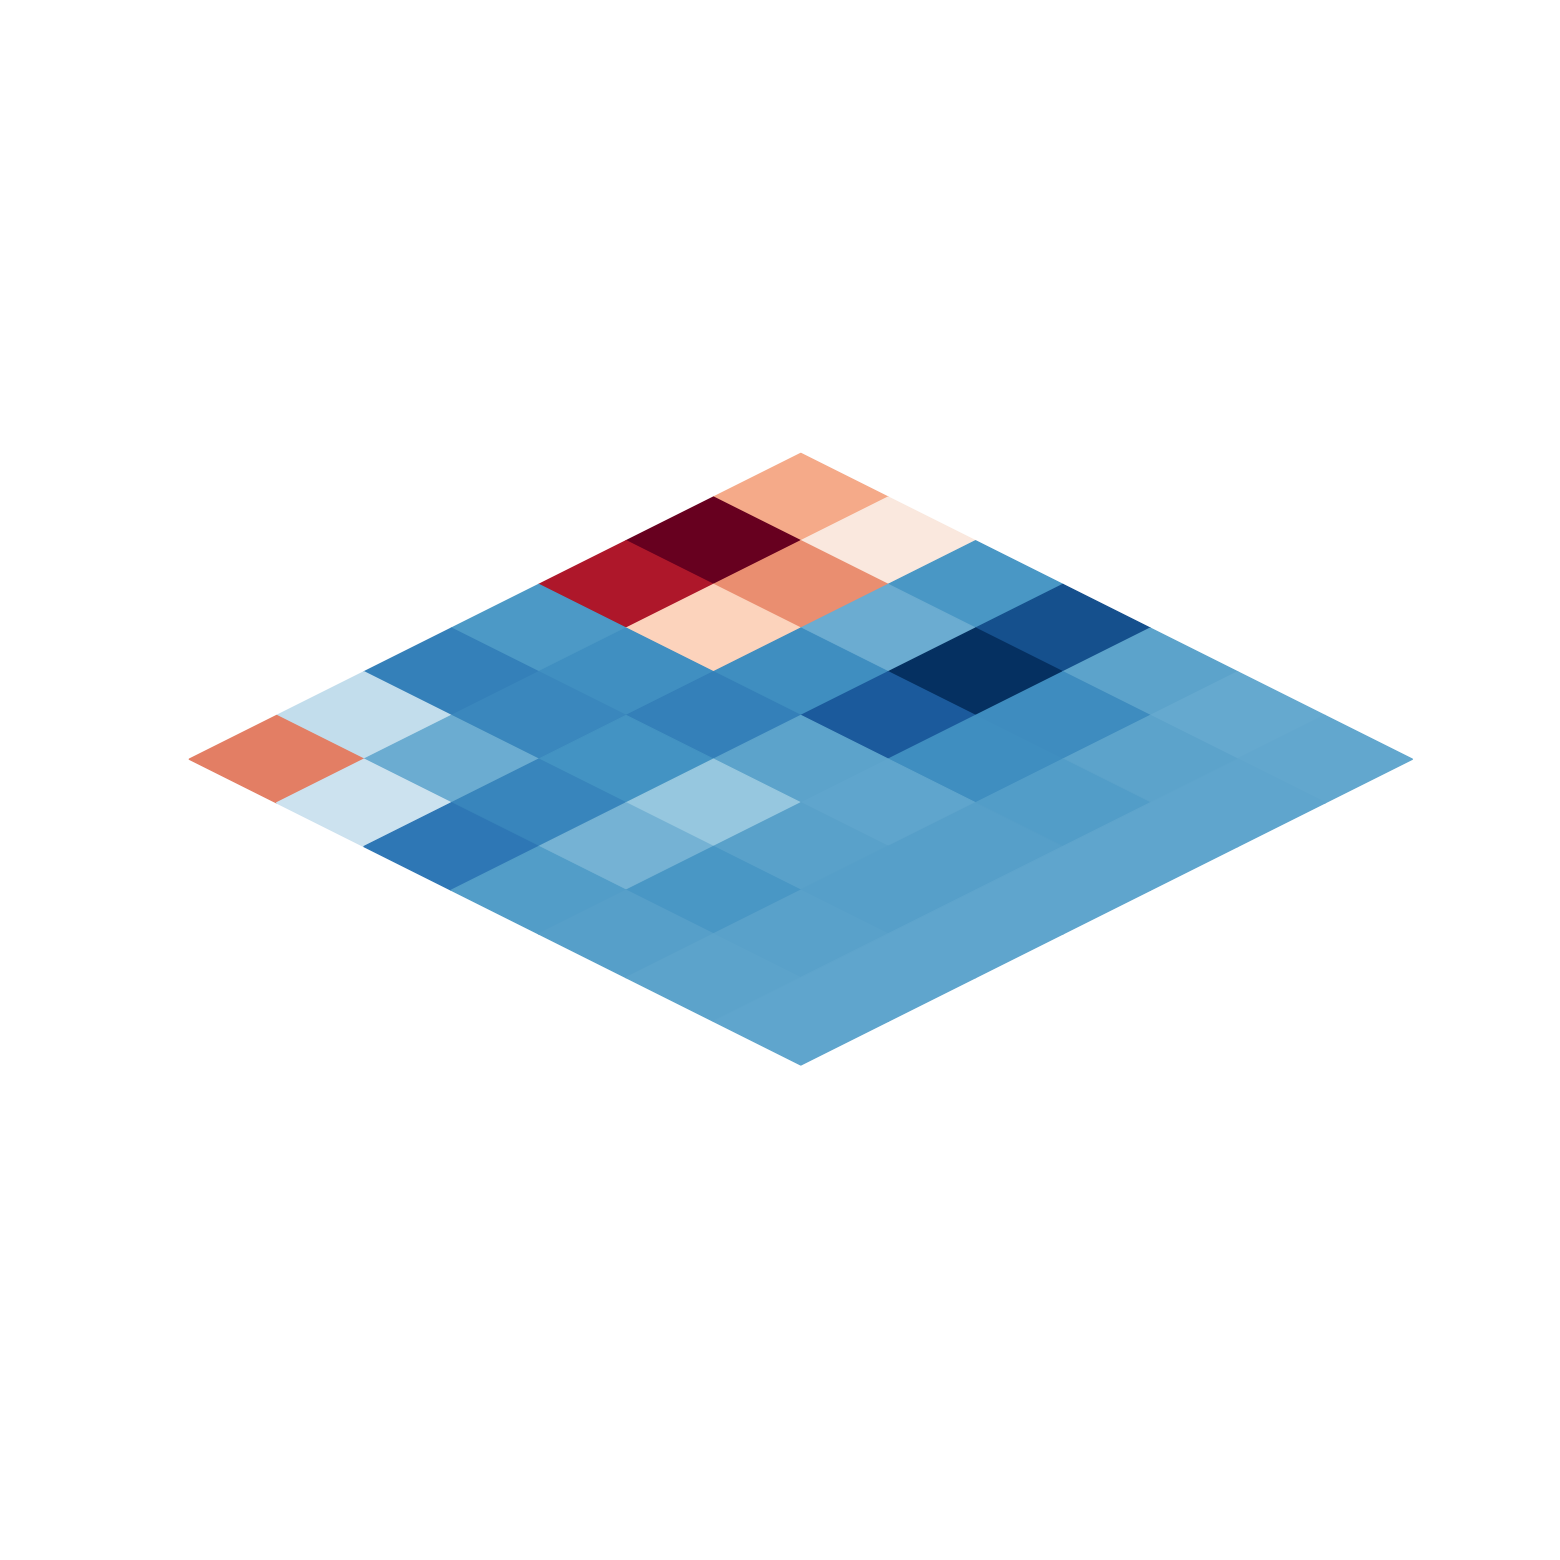

In [144]:
x = data[100].df[0]
# x = torch.from_numpy(x).real
x = (x - x.min()) / (x.max() - x.min())

fig = plot2D_ortho(x, fixed_axes=(1, 2), subs_2d=(1, 2))
# fig.savefig("sspace.pdf", bbox_inches="tight")